In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
%matplotlib inline

## Homework 5: Due 10/09/25 by 11:59 PM

## Background and Definitions

By $L_{2}(\mathbb{R})$ we mean that class of functions $f(x)$ such that

$$
\left|\left|f\right|\right|_{2}^{2} = \left<f,f \right> = \int_{-\infty}^{\infty}\left|f(x)\right|^{2}dx < \infty
$$

Affiliated with the inner product, we have the Cauchy--Schwarz inequality:

$$
\left|\left<f,g \right>\right| \leq \left|\left|f\right|\right|_{2}\left|\left|g\right|\right|_{2}
$$

We define the Haar wavelets via the scaling function 

$$
\phi(x) = \left\{\begin{array}{rl}1 & x \in [0,1] \\ 0 & x \notin [0,1] \end{array}\right.
$$

and the wavelet function

$$
\psi(x) = \left\{\begin{array}{rl} 1 & x \in [0,1/2) \\ -1 & x\in[1/2, 1] \\ 0 & x \notin [0,1] \end{array}\right.
$$

This gives rise to the scaled/translated functions $\phi_{j,n}(x) = 2^{-j/2}\phi(2^{-j}x - n)$ and $\psi_{j,n}(x) = 2^{-j/2}\psi(2^{-j}x - n)$ with corresponding _approximation_ spaces $\mathbb{A}_{j}$ defined by 

$$
\mathbb{A}_{j} = \text{Span}_{n}\left\{\phi_{j,n}\right\}
$$

and _detail_ spaces 

$$
\mathbb{D}_{j} = \text{Span}_{n}\left\{\psi_{j,n}\right\}
$$

We will take it as a given that $\mathbb{A}_{j-1} = \mathbb{A}_{j} \oplus \mathbb{D}_{j}$ and that 
$$
\cdots \subset \mathbb{A}_{1} \subset \mathbb{A}_{0} \subset \mathbb{A}_{-1} \subset \cdots
$$
and that $\mathbb{D}_{j}\perp \mathbb{D}_{k}$ for all $j\neq k$.

## Problems
For $f(x)\in L_{2}(\mathbb{R})$, define $\tilde{f}_{j}(x) \in \mathbb{A}_{j}$ to be

$$
\tilde{f}_{j}(x) = \sum_{n=-\infty}^{\infty}\left<f,\phi_{j,n}\right>\phi_{j,n}(x)
$$

and define $\hat{f}_{j}(x)\in \mathbb{D}_{j}$ to be 

$$
\hat{f}_{j}(x) = \sum_{n=-\infty}^{\infty}\hat{f}_{jn}\psi_{j,n}(x), ~ \hat{f}_{jn} = \left<f,\psi_{j,n}\right>
$$

As for the infinite sums which we use to define $\tilde{f}_{j}$ and $\hat{f}_{j}$, we tacitly use the fact that Bessel's inequality implies that those sums are Cauchy sequences in $L_{2}(\mathbb{R})$ so that convergence to a well defined limit within $L_{2}(\mathbb{R})$ is a given via using the completeness of $L_{2}(\mathbb{R})$.

**Problem 1**: Prove that 
\begin{align*}
\left|\left|f - \tilde{f}_{j}\right|\right|_{2}^{2} = & \left|\left|f\right|\right|_{2}^{2} - \left|\left|\tilde{f}_{j}\right|\right|_{2}^{2}\\
= & \left|\left|f\right|\right|_{2}^{2} - \sum_{n=-\infty}^{\infty}\left|\left<f,\phi_{j,n}\right>\right|^{2}
\end{align*}

$$
\left|\left|f - \tilde{f}_{j}\right|\right|_{2}^{2} = \left<f - \tilde{f}_{j},f - \tilde{f}_{j}\right>
$$

$$
= \left<f, f\right> - 2\left<f, \tilde{f}_{j}\right> + \left<\tilde{f}_{j}, \tilde{f}_{j}\right>
$$

Middle term $\left<f, \tilde{f}_{j}\right>$:

$$
\left<f, \tilde{f}_{j}\right> = \left<f, \sum_{n=-\infty}^{\infty}\left<f, \phi_{j,n}\right>\phi_{j,n}\right>
$$

$$
= \sum_{n=-\infty}^{\infty}\left<f, \phi_{j,n}\right>^{*}\left<f, \phi_{j,n}\right>
= \sum_{n=-\infty}^{\infty}\left|\left<f, \phi_{j,n}\right>\right|^{2}
$$

Third term $\left<\tilde{f}_{j}, \tilde{f}_{j}\right>$:

$$
\left<\tilde{f}_{j}, \tilde{f}_{j}\right> = \sum_{m=-\infty}^{\infty}\left(\left<f, \phi_{j,m}\right>\phi_{j,m}\right)^{*}
\sum_{n=-\infty}^{\infty}\left<f, \phi_{j,n}\right>\phi_{j,n}
$$

$$
= \sum_{m=-\infty}^{\infty} \sum_{n=-\infty}^{\infty} \left<f, \phi_{j,m}\right>^{*} \left<f, \phi_{j,n}\right> \left<\phi_{j,m}, \phi_{j,n}\right>
$$

This yields the Kronecker delta $\delta_{mn}$ that requires the $m$ and $n$ indices to be equal or otherwise zero. So we know that the only terms that don't vanish are when $n=m$. Therefore,

$$
= \sum_{n=-\infty}^{\infty} \left<f, \phi_{j,n}\right>^{*} \left<f, \phi_{j,n}\right>
= \sum_{n=-\infty}^{\infty}\left|\left<f, \phi_{j,n}\right>\right|^{2}
$$

and we can conclude

$$
\left<f, \tilde{f}_{j}\right> = \left<\tilde{f}_{j}, \tilde{f}_{j}\right>
$$

which brings us to

$$
\left<f, f\right> - 2\left<f, \tilde{f}_{j}\right> + \left<\tilde{f}_{j}, \tilde{f}_{j}\right> = 
\left<f, f\right> - \left<f, \tilde{f}_{j}\right>
$$

$$
= \left|\left|f\right|\right|_{2}^{2} - \left|\left|\tilde{f}_{j}\right|\right|_{2}^{2}
$$

$$
= \left|\left|f\right|\right|_{2}^{2} - \sum_{n=-\infty}^{\infty}\left|\left<f,\phi_{j,n}\right>\right|^{2},
$$

as desired.

**Problem 2**: Given that 
$$
\left<f,\phi_{j,n}\right> = 2^{-j/2}\int_{2^{j}n}^{2^{j}(n+1)}f(x) dx
$$
using the Mean-Value Theorem for integrals, show that there exists $\tilde{x}_{j,n}\in[2^{j}n, 2^{j}(n+1)]$ such that
$$
\left<f,\phi_{j,n}\right> = 2^{j/2} f(\tilde{x}_{j,n})
$$

The Mean-Value Theorem states that on a closed interval $[a,b]$, the area under the curve is equal to the average of the function on that interval times $(b-a)$. Or

$$
\int_{a}^{b} f(x)dx = f(c)(b-a)
$$

where $f(c)$ is the average of $f$ on $[a,b]$.

Let $a = 2^{j}n, b = 2^{(j+1)}n$, then, by the Mean Value Theorem for integrals, there exists $\tilde{x}_{j,n}$ in $[a,b]$ such that

$$
2^{-j/2}\int_{a}^{b} f(x)dx = 2^{-j/2}f(\tilde{x}_{j,n})(b-a) = 2^{j/2}f(\tilde{x}_{j,n}).
$$


**Problem 3** (Graduate): Suppose now that $f$ is continuous and is only non-zero on the interval $[-L, L]$.  For $j<0$, show that 

$$
\tilde{f}_{j}(x) = \sum_{n=-\lceil L2^{-j} \rceil}^{\lceil L2^{-j} \rceil}f(\tilde{x}_{j,n})\phi\left(2^{-j}x-n\right).
$$

From this show that 
$$
\left|\tilde{f}_{j}(x)\right|^{2} = \sum_{n=-\lceil L2^{-j} \rceil}^{\lceil L2^{-j} \rceil}\left|f(\tilde{x}_{j,n})\right|^{2}\phi\left(2^{-j}x-n\right),
$$

and thus show that 

$$
\int_{-L}^{L}\left|\tilde{f}_{j}(x)\right|^{2} dx = 2^{j} \sum_{n=-\lceil L2^{-j} \rceil}^{\lceil L2^{-j} \rceil}\left|f(\tilde{x}_{j,n})\right|^{2}
$$

Use a Riemann Sum argument and Problem 1 to then show that 

$$
\lim_{j\rightarrow -\infty}\left|\left|f - \tilde{f}_{j}\right|\right|_{2} = 0
$$

Note, compactly supported, continuous functions are dense in $L_{2}(\mathbb{R})$, so we get the result to carry over to all of $L_{2}(\mathbb{R})$.

**Problem 4** (Graduate): Show then that 
$$
L_{2}(\mathbb{R}) = \bigoplus_{j=-\infty}^{\infty} \mathbb{D}_{j}
$$

From this, we see that we can define the _wavelet transform_ of $f(x)$ to be 

$$
f(x) = \sum_{j=-\infty}^{\infty}\sum_{n=-\infty}^{\infty}\hat{f}_{jn}\psi_{jn}(x)
$$

**Problem 5**: Using beans.jpg, or whichever (school appropriate) image you prefer, and following the model for how we built an image approximation using the approximation coefficiets from a wavelet decomposition, create corresponding images for each of the different levels of detail in decomposition.  Use three levels of decomposition.  

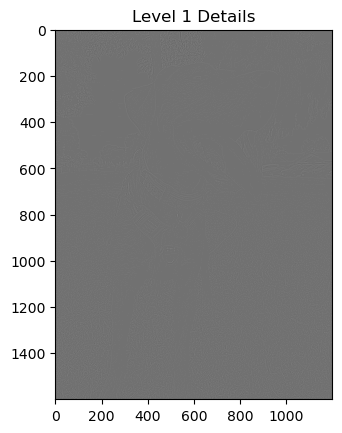

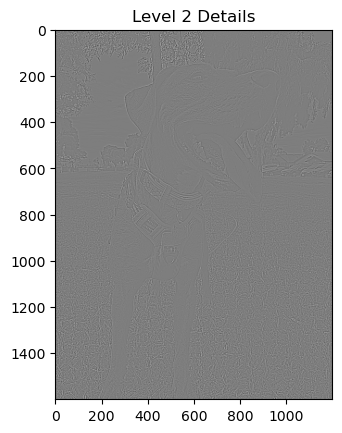

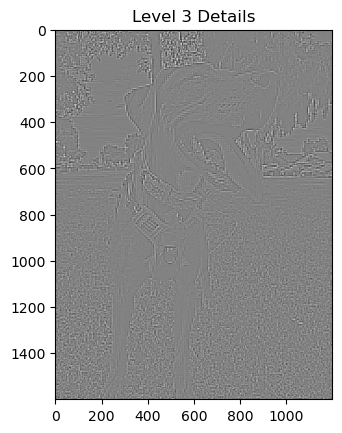

In [ ]:
from skimage import io
from scipy.fft import fft, ifft, fftshift, fft2, ifft2
from scipy.signal import stft
import pywt

beans = io.imread('beans.jpg', as_gray=True)

coeffs = pywt.wavedec2(beans, 'db1', level=3)

keep_L1 = [
    np.zeros(coeffs[0].shape),
    (np.zeros(coeffs[1][0].shape), np.zeros(coeffs[1][1].shape), np.zeros(coeffs[1][2].shape)),
    (np.zeros(coeffs[2][0].shape), np.zeros(coeffs[2][1].shape), np.zeros(coeffs[2][2].shape)),
    coeffs[3]
]

img_L1 = pywt.waverec2(keep_L1, 'db1')
plt.imshow(img_L1, cmap='gray')
plt.title('Level 1 Details')
plt.show()

keep_L2 = [
    np.zeros(coeffs[0].shape),
    (np.zeros(coeffs[1][0].shape), np.zeros(coeffs[1][1].shape), np.zeros(coeffs[1][2].shape)),
    coeffs[2],
    (np.zeros(coeffs[3][0].shape), np.zeros(coeffs[3][1].shape), np.zeros(coeffs[3][2].shape))
]

img_L2 = pywt.waverec2(keep_L2, 'db1')
plt.imshow(img_L2, cmap='gray')
plt.title('Level 2 Details')
plt.show()

keep_L3 = [
    np.zeros(coeffs[0].shape),
    coeffs[1],
    (np.zeros(coeffs[2][0].shape), np.zeros(coeffs[2][1].shape), np.zeros(coeffs[2][2].shape)),
    (np.zeros(coeffs[3][0].shape), np.zeros(coeffs[3][1].shape), np.zeros(coeffs[3][2].shape))
]

img_L3 = pywt.waverec2(keep_L3, 'db1')
plt.imshow(img_L3, cmap='gray')
plt.title('Level 3 Details')
plt.show()

**Problem 6**: Using the results from above, generate Fourier transforms of each detail image you reconstruct.  Explain and compare your results from doing this.  

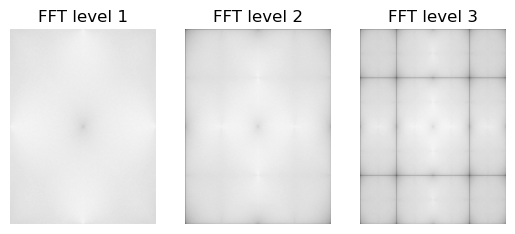

In [40]:
freq1 = np.log10(np.abs(fftshift(fft2(img_L1))) + 1e-10)
freq2 = np.log10(np.abs(fftshift(fft2(img_L2))) + 1e-10)
freq3 = np.log10(np.abs(fftshift(fft2(img_L3))) + 1e-10)

plt.subplot(131)
plt.imshow(freq1, cmap='gray')
plt.title('FFT level 1')
plt.axis('off')

plt.subplot(132)
plt.imshow(freq2, cmap='gray')
plt.title('FFT level 2')
plt.axis('off')

plt.subplot(133)
plt.imshow(freq3, cmap='gray')
plt.title('FFT level 3')
plt.axis('off');

For the detail plots, in the level one plot we see essentially just some gray noise, as it captures the finest details. There is a bit of formation of the shape of beans but ultimately it is hard to make out. The most notable part of this plot is the tree leaves in the top middle, which show some definition. The level two plot captures the next finest, or next least fine (I forgot what terminology we came up for that in class) details and we start to see definition around points in the image where there is substantial (local) change in frequency, i.e. where the sky meets the backdrop/horizon, and beans' head against the whole backdrop. There is more discrepancy when looking at the lower half of the image, however, since that is where the background is grass, and such changes in frequency are harder to make out. Level three is where we see our most coarse details being captured, and the large scale countours of the image, i.e. the outline of beans and the horizon/houses in the background pop out while fine textures like her fur and the grass are still suppressed.

In the FFT plots of each detail, we start to see a grid shape appear. This is because as the level number increases, the resolution of the image is halved, and in frequency space this creates repeated copies of the spectrum and the edges of the plot (noticable in level 2) are the borders of each of these supspaces, which gives off the grid pattern. Each space is basically showing the same chunk of distrubution, which gives it the smooth grid vibe rather than busy texture.